<a href="https://colab.research.google.com/github/ridheekshanallu98/Fraud_Transaction_Detection/blob/main/fraud_transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
fraud=pd.read_csv("/content/synthetic_fraud_dataset.csv")

In [ ]:
fraud.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


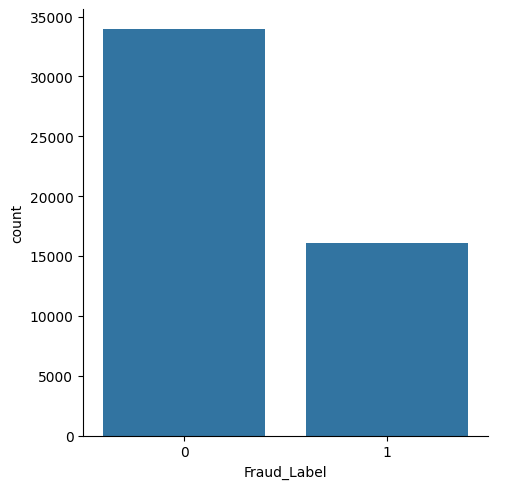

In [ ]:
sns.catplot(x='Fraud_Label',data=fraud,kind='count')

In [ ]:
fraud["Fraud_Label"].value_counts()

,count
Fraud_Label,
0,33933
1,16067


In [ ]:
fraud["Fraud_Label"].value_counts(normalize=True) * 100

,proportion
Fraud_Label,
0,67.866
1,32.134


In [ ]:
fraud = fraud.drop(["Transaction_ID","User_ID"],axis=1)
fraud = fraud.drop(["Risk_Score","Previous_Fraudulent_Activity"],axis=1)

In [ ]:
fraud = pd.get_dummies(fraud, columns=["Transaction_Type", "Device_Type",
                                 "Location", "Merchant_Category",
                                 "Card_Type", "Authentication_Method"], drop_first=True)

In [ ]:
fraud["Timestamp"] = pd.to_datetime(fraud["Timestamp"])
fraud["Hour"] = fraud["Timestamp"].dt.hour
fraud["Day"] = fraud["Timestamp"].dt.day
fraud["Weekday"] = fraud["Timestamp"].dt.weekday
fraud = fraud.drop("Timestamp", axis=1)

In [ ]:

X = fraud.drop("Fraud_Label", axis=1)
y = fraud["Fraud_Label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
random_forest = RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = random_forest.predict(X_test)

In [ ]:
test_data_accuracy=accuracy_score(y_pred,y_test)
print("Accuracy on test data:",test_data_accuracy)

Accuracy on test data: 0.8772


checking precision and recall

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      6787
           1       1.00      0.62      0.76      3213

    accuracy                           0.88     10000
   macro avg       0.92      0.81      0.84     10000
weighted avg       0.90      0.88      0.87     10000

